<a href="https://colab.research.google.com/github/Yeshwanth369/ML-DL-Projects/blob/main/LangGraph_Graph_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
  message : str

def greeting_node(state : AgentState) -> AgentState:
  """ Simple node that adds a greeting message to the state"""

  state['message'] = 'Hi '+state['message']

  return state


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("Greeter", greeting_node)

graph.set_entry_point("Greeter")
graph.set_finish_point("Greeter")

app = graph.compile()

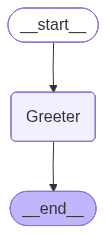

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"message":"Bob"})

result["message"]

'Hi Bob'

**#Section 2**

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
  values : List[int]
  name : str
  operation : str
  result : int


def node_processing(state:AgentState) -> AgentState:
  if state["operation"] == "+":
    state["result"] = " Hi "+state["name"]+", your answer is : "+str(sum(state["values"]))
  elif state["operation"] == "-":
    state["result"] = " Hi "+state["name"]+", your answer is : "+str(sub(state["values"]))
  elif state["operation"] == "*":
    state["result"] = " Hi "+state["name"]+", your answer is : "+str(math.prod(state["values"]))
  else :
    state["result"] = "Invalid"

  return state

graph = StateGraph(AgentState)

graph.add_node("Processing", node_processing)

graph.set_entry_point("Processing")
graph.set_finish_point("Processing")

app = graph.compile()

answers = app.invoke({"name": "Jack Sparrow","values": [1,2,3,4] , "operation": "*"})

In [ ]:
print(answers)

{'values': [1, 2, 3, 4], 'name': 'Jack Sparrow', 'operation': '*', 'result': ' Hi Jack Sparrow, your answer is : 24'}


**# Section 3**

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
  name : str
  age : int
  skills : List[str]
  result : str

def node_1(state : AgentState) -> AgentState:
  state["result"] = f"Hi {state["name"] }"
  return state

def node_2(state : AgentState) -> AgentState:
  state["result"] = state[result] + f" You are {state["age"]} old!"
  return state

def node_3(state : AgentState) -> AgentState:
  state["result"] = state[result] + f" You have skills {"".join(state["skills"])} "
  return state


graph.add_node("personalize", node_1)
graph.add_node("age_description", node_2)
graph.add_node("skills_description", node_3)

graph.set_entry_point("personalize")
graph.add_edge("personalize", "age_description")
graph.add_edge("age_description", "skills_description")
graph.set_finish_point("skills_description")
app_1 = graph.compile()


#from IPython.display import Image, display
#display(Image(app.get_graph().draw_mermaid_png()))

**# Section 4**

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  number1 : int
  operation1 : str
  number2 : int
  number3 : int
  operation2 : str
  number4 : int
  finalNumber : int

In [ ]:
def adder1(state:AgentState) -> AgentState:
  state["finalNumber"] = state["number1"] + state["number2"]
  return state

def subtractor1(state:AgentState) -> AgentState:
  state["finalNumber"] = state["number1"] - state["number2"]
  return state

def adder2(state:AgentState) -> AgentState:
  state["finalNumber"] = state["finalNumber"] + state["number3"] +state["number4"]
  return state


def subtractor2(state:AgentState) -> AgentState:
  state["finalNumber"] = state["finalNumber"] + state["number2"] - state["number3"]
  return state


In [ ]:
def decide_next_node1(state:AgentState) -> AgentState:
  """This Node will select the next node of the graph"""
  if state["operation1"] == "+":
    return "addition_operation" # Edge
  elif state["operation1"] == "-":
    return "subtraction_operation" # Edge

def decide_next_node2(state:AgentState) -> AgentState:
  """This Node will select the next node of the graph"""
  if state["operation2"] == "+":
    return "addition_operation" # Edge
  elif state["operation2"] == "-":
    return "subtraction_operation" # Edge

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("addition_operation1", adder1)
graph.add_node("subtraction_operation1", subtractor1)
graph.add_node("router1", lambda state:state) # passthrough function
graph.add_node("router2", lambda state:state)
graph.add_node("addition_operation2", adder2)
graph.add_node("subtraction_operation2", subtractor2)


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("addition_operation1", adder1)
graph.add_node("subtraction_operation1", subtractor1)
graph.add_node("router1", lambda state:state) # passthrough function
graph.add_node("router2", lambda state:state)
graph.add_node("addition_operation2", adder2)
graph.add_node("subtraction_operation2", subtractor2)

graph.add_edge(START, "router1")
graph.add_conditional_edges("router1",decide_next_node1,
                            {
                                #Edge : Node
                                "addition_operation" : "addition_operation1",
                                "subtraction_operation" : "subtraction_operation1"
                            }
                            )
graph.add_edge("addition_operation1","router2")
graph.add_edge("subtraction_operation1","router2")

graph.add_conditional_edges("router2", decide_next_node2,
                            {
                                "addition_operation" : "addition_operation2",
                                "subtraction_operation" : "subtraction_operation2"
                            }
                            )
graph.add_edge("addition_operation2", END)
graph.add_edge("subtraction_operation2", END)

app = graph.compile()

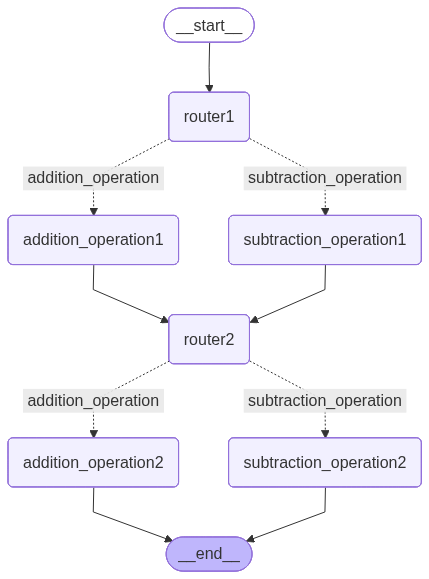

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = AgentState(number1 = 10, operation1="-", number2 = 5, number3 = 7, number4=2, operation2="+" )

app.invoke(initial_state)

{'number1': 10,
 'operation1': '-',
 'number2': 5,
 'number3': 7,
 'operation2': '+',
 'number4': 2,
 'finalNumber': 14}

**#Section 5**

In [ ]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END
import random

class AgentState(TypedDict):
  player_name : str
  guesses : List[int]
  attempts : int
  lower_bound: int
  upper_bound: int
  state: Optional[str] # Corrected syntax, allowing None initially
  answer: int

def greeting(state:AgentState) -> AgentState:
  state["player_name"] = "Hi, " + state["player_name"]
  state["attempts"] = 0
  if "guesses" not in state or state["guesses"] is None:
    state["guesses"] = [] # Ensure 'guesses' is initialized as an empty list
  return state

def generate_rand_number(state:AgentState)->AgentState:
  current_attempts = state.get("attempts", 0)

  if current_attempts < 7:
    # Ensure required fields are present
    if "answer" not in state or "lower_bound" not in state or "upper_bound" not in state:
        raise ValueError("Missing 'answer', 'lower_bound', or 'upper_bound' in state.")

    target_answer = state["answer"]
    rand_number = random.randint(state["lower_bound"], state["upper_bound"])


    print(f"Current guesses: {state.get("guesses", [])}, Generated guess: {rand_number}")


    if "guesses" not in state or state["guesses"] is None:
        state["guesses"] = [] # Re-initialize if for some reason it's not a list
    state["guesses"].append(rand_number)

    if rand_number != target_answer:
      if rand_number > target_answer:
        state["upper_bound"] = rand_number
      else:
        state["lower_bound"] = rand_number
      state["attempts"] = current_attempts + 1
      state["state"] = "continue"
    else:
      state["state"] = "exit" # Guessed correctly
  else:
    state["state"] = "exit" # Ran out of attempts
  return state

def check_game_state(state:AgentState)->str:
  if state.get("state") == "continue":
    return "continue"
  else:
    return "exit"


graph = StateGraph(AgentState)

graph.add_node("greeting", greeting)
graph.add_node("guess",generate_rand_number)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "guess")
graph.add_conditional_edges("guess", check_game_state, # Use the correctly named function
                            {
                                "continue" : "guess", # Loop back to guess node
                                "exit" : END
                            }
                            )

app = graph.compile()


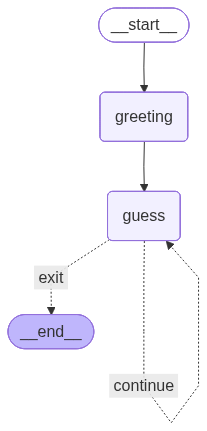

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20, "answer": 15})


Current guesses: [], Generated guess: 7
Current guesses: [7], Generated guess: 13
Current guesses: [7, 13], Generated guess: 20
Current guesses: [7, 13, 20], Generated guess: 14
Current guesses: [7, 13, 20, 14], Generated guess: 15


**# Agents**

In [ ]:
OPENAI_API_KEY=""
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.0 MB/s eta 0:00:00


In [ ]:
!pip install langchain_openai
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
import os # Import os module to potentially access environment variables if needed


class AgentState(TypedDict):
  messages: List[HumanMessage]

llm = ChatOpenAI(model='gpt-4o',
                 api_key = OPENAI_API_KEY, # Corrected: 'apiKey' to 'api_key'
                 )

def process(state:AgentState) -> AgentState:
  response = llm.invoke(state["messages"])
  print(f"\nAI: {response.content}")
  return state

graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.set_entry_point("process")
graph.set_finish_point("process")

agent = graph.compile()

user_input = input("Enter ")
while user_input != "exit":
  agent.invoke({"messages": [HumanMessage(content=user_input)]})
  user_input = input("Enter")
#

EnterHi, How are You

AI: Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?
Enterhow was your day

AI: I'm here to assist you 24/7, so my "day" doesn't quite have the highs and lows that humans experience. But I'm ready to help you with whatever you need! How can I assist you today?
Enterexit


**# ChatBot with memory**

In [ ]:
import os
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  messages: List[Union[HumanMessage, AIMessage]]

llm = ChatOpenAI(model="gpt-4o",api_key = OPENAI_API_KEY)

def process(state:AgentState)->AgentState:
  response = llm.invoke(state["messages"])
  state["messages"].append(AIMessage(content=response.content))
  print(f'\n AI : {response.content}') # Corrected: used .content instead of ["content"]
  return state


In [ ]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

agent = graph.compile()

In [ ]:
 conversation_history = []

user_input = input("Enter:  ")
while user_input != "exist":
  conversation_history.append(HumanMessage(content = user_input))
  #initiating the graph
  result = agent.invoke({"messages": conversation_history})

  print(result["messages"])

  conversation_history = result["messages"]

  if len(conversation_history) > 5:
    del conversation_history[0] # Reduce the memory and to maintain specific context window.g

  user_input = input("Enter:  ")


Enter:  hi

 AI : Hello! How can I assist you today?
[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
Enter:  hi

 AI : Hi again! What can I do for you today?
[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi again! What can I do for you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
Enter:  hik

 AI : Hello! If you meant "hi," I'm here to help. Let me know if there's anything specific you'd like to talk about or if you have any questions!
[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='

In [ ]:
len(conversation_history)

8

In [ ]:
for i in conversation_history:
  print(i+"/n")

input_variables=[] input_types={} partial_variables={} messages=[HumanMessage(content='hik', additional_kwargs={}, response_metadata={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='/n'), additional_kwargs={})]
input_variables=[] input_types={} partial_variables={} messages=[AIMessage(content='Hello! If you meant "hi," I\'m here to help. Let me know if there\'s anything specific you\'d like to talk about or if you have any questions!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='/n'), additional_kwargs={})]
input_variables=[] input_types={} partial_variables={} messages=[HumanMessage(content='good morning', additional_kwargs={}, response_metadata={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, temp

**# ReAct : Reasoning and Acting**

In [ ]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages




In [ ]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages



class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def add(a:int, b:int) -> int:
  """ Addition Operation"""
  return a + b

tools =[add]

model = ChatOpenAI(model="gpt-4o",api_key = OPENAI_API_KEY).bind_tools(tools)

def model_call(state:AgentState) -> AgentState:
  system_prompt = SystemMessage(content = "you are my AI assistant, please answer my query to the best of your ability.")
  response = model.invoke([system_prompt] + state["messages"])
  return {"messages": [response]}


def should_continue(state:AgentState) :
  messages = state["messages"]
  last_message = messages[-1]
  if not last_message.tool_calls:
    return "end"
  else:
    return "continue"

graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tool_node", tool_node)

graph.set_entry_point("our_agent")
graph.add_conditional_edges("our_agent", should_continue,
                            {
                                "continue" : "tool_node",
                                "end" : END
                            }
)

graph.add_edge("tool_node", "our_agent")
graph.set_finish_point("our_agent")

app = graph.compile()

def print_stream(stream):
  for s in stream:
    # 's' is typically {'node_name': {'messages': [...]}}
    # We want to get the inner dictionary's 'messages' list.
    # There should only be one key in 's' for each step in this simple graph.
    if s: # Ensure 's' is not empty
      node_output = next(iter(s.values())) # Get the value of the single node_name key
      if 'messages' in node_output:
        for message in node_output['messages']:
          message.pretty_print()


In [ ]:
inputs = {"messages":[("user","Add 3 + 4.")]}
print_stream(app.stream(inputs)) # Removed stream_node="values"

================================== Ai Message ==================================
Tool Calls:
  add (call_hqNGzYW7OgjanEjzxx1CvEiR)
 Call ID: call_hqNGzYW7OgjanEjzxx1CvEiR
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The result of 3 + 4 is 7.


#Drafter

In [ ]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

document_content = ""


class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def update(content: str)->str:
  """Update the document with the provided ccontent"""
  global document_content
  document_content = content
  return f" Document updated with {content}\n"

@tool
def save(filename: str)->str:
  """Save the current document
  Args:
       filename: Name for the text file.
  """
tools = [update,save]
  if not filename.endswitch('.txt'):
    filename = f"{filename}.txt"

try:
  with open(filename,'w')as file:
    file.write(document_content)
    print(f"\nDocument saved to {filename}")
    return f"Document saved to {filename}"
except Exception as e:
  print(f"Error saving document: {e}")
  return f"Error saving document: {str(e)}"

tools = [update, save]

model = ChatOpenAI(model="gpt-4o",api_key = OPENAI_API_KEY).bind_tools(tools)

